In [1]:
%matplotlib inline

---
# Datasets & DataLoaders
---


PyTorch provides two data primitives: ``torch.utils.data.DataLoader`` and ``torch.utils.data.Dataset``
that allow you to use pre-loaded datasets as well as your own data.
``Dataset`` stores the samples and their corresponding labels, and ``DataLoader`` wraps an iterable around
the ``Dataset`` to enable easy access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such as FashionMNIST) that
subclass ``torch.utils.data.Dataset`` and implement functions specific to the particular data.
They can be used to prototype and benchmark your model. You can find them
here: [Image Datasets](https://pytorch.org/vision/stable/datasets.html),
[Text Datasets](https://pytorch.org/text/stable/datasets.html), and
[Audio Datasets](https://pytorch.org/audio/stable/datasets.html)




## 0. Importing PyTorch and setting up device-agnostic code

In [2]:
import torch
from torch import nn

torch.__version__

'2.11.0+cu128'

In [3]:
# Setup device-agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
!nvidia-smi

Sat Jun 20 12:16:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             16W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## 1. Get data

####**Start Small and Upgrade if Necessary**

First things first we need some data.

We're going to start small.

Because we're not looking to train the biggest model or use the biggest dataset yet.

Machine learning is an iterative process, start small, get something working and increase when necessary.

The data we're going to be using is a subset of the [FashionMNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist).

Fashion-MNIST is a popular computer vision benchmark dataset consisting of 70,000 grayscale images of fashion products across 10 categories. It was created as a drop-in replacement for the original MNIST handwritten digits dataset.

Can you think of a computer program that can automatically identify different types of clothing items from images?

I can.

A machine learning model!

Specifically, a PyTorch computer vision model like we covered in Notebook 03.

Rather than working with all 70,000 images immediately, we'll begin with a smaller subset of the dataset. Starting with a reduced dataset allows us to iterate quickly, debug our code efficiently, and verify that our training pipeline works correctly before scaling up.

```
fashion_mnist_subset/
├── train/
│ ├── T_shirt_top/
│ ├── Trouser/
│ ├── Pullover/
│ ├── Dress/
│ ├── Coat/
│ ├── Sandal/
│ ├── Shirt/
│ ├── Sneaker/
│ ├── Bag/
│ └── Ankle_boot/
└── test/
  ├── T_shirt_top/
  ├── Trouser/
  ├── Pullover/
  ├── Dress/
  ├── Coat/
  ├── Sandal/
  ├── Shirt/
  ├── Sneaker/
  ├── Bag/
  └── Ankle_boot/
```
Each class folder contains grayscale PNG images belonging to that category.

Let's write some code to download the formatted data from GitHub.

> **Note:** The dataset we're about to use has been pre-formatted for what we'd like to use it for. However, you'll often have to format your own datasets for whatever problem you're working on. This is a regular practice in the machine learning world.

In [5]:
import requests
import zipfile
from pathlib import Path

In [6]:
# Setup path to a dara folder
data_path=Path("data/")
image_path=data_path / "fashion_mnist_subset"

# If the image folder doen't exist, download it and prepare it
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"Did not find {image_path} directory, creating one...")
  image_path.mkdir(parents=True, exist_ok=True)

# Download fashion_mnist_subset data
with open(data_path / "fashion_mnist_subset.zip", "wb") as f:
  request=requests.get("https://github.com/alpha023/dataset/raw/main/fashion_mnist_subset.zip")
  print("Downloading FashionMNIST data...")
  f.write(request.content)

# Unzip the content of the file
with zipfile.ZipFile(data_path / "fashion_mnist_subset.zip", "r") as zip_ref:
  print("Unzipping fashion_mnist_subset data...")
  zip_ref.extractall(image_path)

data/fashion_mnist_subset directory already exists... skipping download
Unzipping fashion_mnist_subset data...


In [7]:
items=list(image_path.iterdir())

In [8]:
items_train=list(items[1].iterdir())

In [9]:
items_train

[PosixPath('data/fashion_mnist_subset/train/Dress'),
 PosixPath('data/fashion_mnist_subset/train/Coat'),
 PosixPath('data/fashion_mnist_subset/train/T_shirt_top'),
 PosixPath('data/fashion_mnist_subset/train/Shirt'),
 PosixPath('data/fashion_mnist_subset/train/Pullover'),
 PosixPath('data/fashion_mnist_subset/train/Sandal'),
 PosixPath('data/fashion_mnist_subset/train/Ankle_boot'),
 PosixPath('data/fashion_mnist_subset/train/Trouser'),
 PosixPath('data/fashion_mnist_subset/train/Sneaker'),
 PosixPath('data/fashion_mnist_subset/train/Bag')]

In [10]:
for item in image_path.iterdir():
  print(item)

data/fashion_mnist_subset/test
data/fashion_mnist_subset/train


---
## 2. Become one with the data (data preparation)
---
Dataset downloaded!

Time to become one with it.

This is another important step before building a model.

As Abraham Lossfunction said...

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-abraham-lossfunction.png" alt="tweet by mrdbourke, if I had eight hours to build a machine learning model, I'd spend the first 6 hours preparing my dataset" width=800/>

*Data preparation is paramount. Before building a model, become one with the data. Ask: What am I trying to do here

What's inspecting the data and becoming one with it?

Before starting a project or building any kind of model, it's important to understand what data you're working with.

In our case, we have grayscale images of different fashion products stored in a standard image classification format.

Image classification format contains separate classes of images in separate directories named after their corresponding class.

For example, all images of Coat are contained inside the Coat/ directory, while all images of Sneaker are contained inside the Sneaker/ directory.

This directory-based storage format is widely used in computer vision because it is simple, organized, and directly compatible with tools such as PyTorch's ImageFolder dataset class.
You can see an example of the storage format below, the images numbers are arbitrary.

```
fashion_mnist_subset/ <- overall dataset folder
    train/ <- training images
        T_shirt_top/
            T_shirt_top_00000.png
            T_shirt_top_00001.png
            ...
        Trouser/
            Trouser_00000.png
            Trouser_00001.png
            ...
        Pullover/
            Pullover_00000.png
            Pullover_00001.png
            ...
        Dress/
            Dress_00000.png
            Dress_00001.png
            ...
        Coat/
            Coat_00000.png
            Coat_00001.png
            ...
        Sandal/
            Sandal_00000.png
            Sandal_00001.png
            ...
        Shirt/
            Shirt_00000.png
            Shirt_00001.png
            ...
        Sneaker/
            Sneaker_00000.png
            Sneaker_00001.png
            ...
        Bag/
            Bag_00000.png
            Bag_00001.png
            ...
        Ankle_boot/
            Ankle_boot_00000.png
            Ankle_boot_00001.png
            ...

    test/ <- testing images
        T_shirt_top/
            T_shirt_top_00000.png
            T_shirt_top_00001.png
            ...
        Trouser/
            Trouser_00000.png
            Trouser_00001.png
            ...
        Pullover/
            Pullover_00000.png
            Pullover_00001.png
            ...
        Dress/
            Dress_00000.png
            Dress_00001.png
            ...
        Coat/
            Coat_00000.png
            Coat_00001.png
            ...
        Sandal/
            Sandal_00000.png
            Sandal_00001.png
            ...
        Shirt/
            Shirt_00000.png
            Shirt_00001.png
            ...
        Sneaker/
            Sneaker_00000.png
            Sneaker_00001.png
            ...
        Bag/
            Bag_00000.png
            Bag_00001.png
            ...
        Ankle_boot/
            Ankle_boot_00000.png
            Ankle_boot_00001.png
            ...
```

The goal will be to **take this data storage structure and turn it into a dataset usable with PyTorch**.

> **Note:** The structure of the data you work with will vary depending on the problem you're working on. But the premise still remains: become one with the data, then find a way to best turn it into a dataset compatible with PyTorch.

We can inspect what's in our data directory by writing a small helper function to walk through each of the subdirectories and count the files present.

To do so, we'll use Python's in-built [`os.walk()`](https://docs.python.org/3/library/os.html#os.walk).

In [11]:
import os

In [12]:
def walk_through_dir(dir_path):
  for  dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [13]:
# Setup train and testing paths
train_dir=image_path / "train"
test_dir = image_path / "test"

In [14]:
train_dir

PosixPath('data/fashion_mnist_subset/train')

---
##3. Iterating and Visualizing the Dataset

We can index ``Datasets`` manually like a list: ``training_data[index]``.
We use ``matplotlib`` to visualize some samples in our training data.

---


####3.a) Using The Python's Pillow Library
Okay, we've seen how our directory structure is formatted.

Now in the spirit of the data explorer, it's time to *visualize, visualize, visualize!*

Let's write some code to:
1. Get all of the image paths using [`pathlib.Path.glob()`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob) to find all of the files ending in `.png`.
2. Pick a random image path using Python's [`random.choice()`](https://docs.python.org/3/library/random.html#random.choice).
3. Get the image class name using [`pathlib.Path.parent.stem`](https://docs.python.org/3/library/pathlib.html#pathlib.PurePath.parent).
4. And since we're working with images, we'll open the random image path using [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open) (PIL stands for Python Image Library).
5. We'll then show the image and print some metadata.

In [15]:
import random
from PIL import Image

In [16]:
# Set seed
random.seed(42)

# 1. Get all image paths
image_path_list=list(image_path.glob("*/*/*.png"))

In [17]:
len(image_path_list)

6000

In [18]:
# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)


data/fashion_mnist_subset/train/Sneaker/Sneaker_00479.png


In [19]:
# 3. Get image class from path name ( the image class is the name of the directory where the image is stored)
image_class=random_image_path.parent.stem
print(image_class)

Sneaker


In [20]:
# 4. Open image
img=Image.open(random_image_path)

In [21]:
# 5. Print metadata
print(f"Random Image Path: {random_image_path}")
print(f"Image Class: {image_class}")
print(f"Image Size: {img.size}")
img


Random Image Path: data/fashion_mnist_subset/train/Sneaker/Sneaker_00479.png
Image Class: Sneaker
Image Size: (28, 28)


In [22]:
def return_random_image(image_path_list,seed=None):
  if seed:
    random.seed(42)

  # 1. Get all image paths
  image_path_list=list(image_path.glob("*/*/*.png"))
  # 2. Pick a random image path
  random_image_path = random.choice(image_path_list)

  # 3. Get image class from path name ( the image class is the name of the directory where the image is stored)
  image_class=random_image_path.parent.stem

  # 4. Open image
  img=Image.open(random_image_path)

  # 5. Print metadata
  meta_data={
      "Random Image Path":random_image_path,
      "Image Class":image_class,
      "Image Size":img.size
  }
  return meta_data,img

In [23]:
meta_data,img=return_random_image(image_path_list=image_path_list,seed=42)

In [24]:
print(meta_data)

{'Random Image Path': PosixPath('data/fashion_mnist_subset/train/Sneaker/Sneaker_00479.png'), 'Image Class': 'Sneaker', 'Image Size': (28, 28)}


In [25]:
img

####3.b) Using The `matplotlib` Library
We can do the same with [`matplotlib.pyplot.imshow()`](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.imshow.html), except we have to convert the image to a NumPy array first.

In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
img_as_array=np.asarray(img)
print(img_as_array.shape)

(28, 28)


(28, 28)


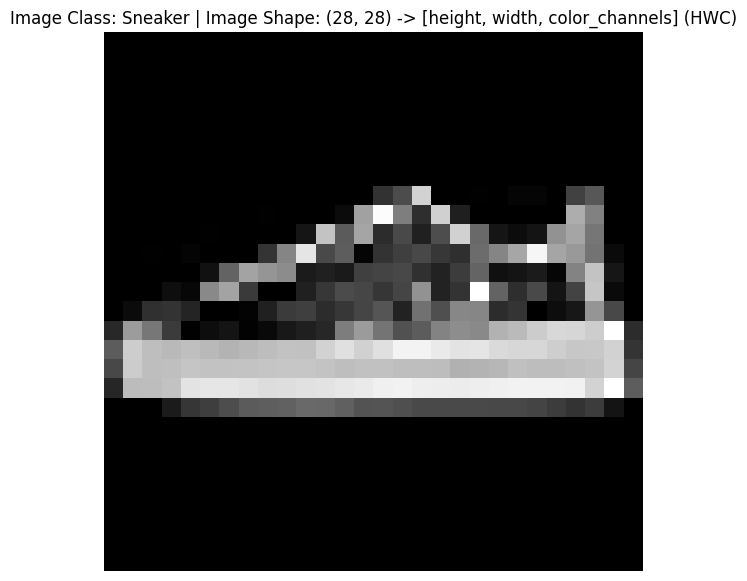

In [28]:
# Turn the image into an array
img_as_array=np.asarray(img)
print(img_as_array.shape)

# Plot the image with matplotlib
plt.figure(figsize=(9,7))
plt.imshow(img_as_array,cmap="grey")
plt.title(f"Image Class: {image_class} | Image Shape: {img_as_array.shape} -> [height, width, color_channels] (HWC)")
plt.axis(False)
plt.show()

In [29]:
image_path_list[0], image_path_list[0].parent.name

(PosixPath('data/fashion_mnist_subset/test/Dress/Dress_00034.png'), 'Dress')

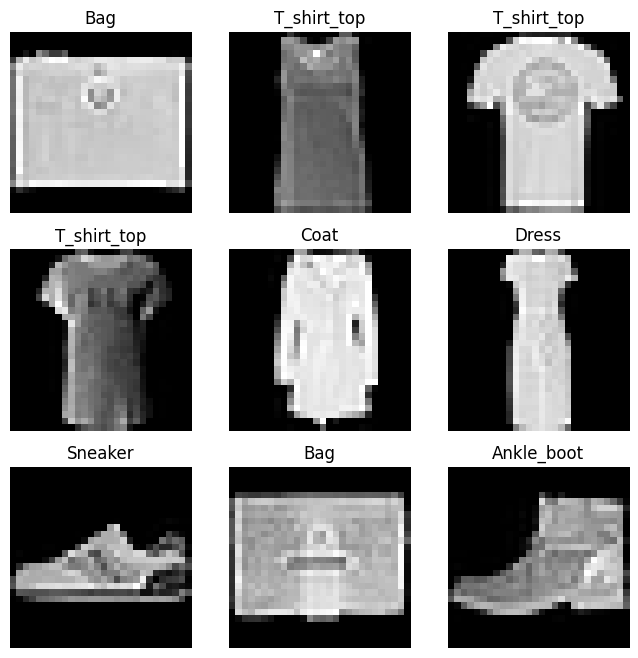

In [30]:
import random
import matplotlib.pyplot as plt
from PIL import Image

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = random.randint(0, len(image_path_list) - 1)

    img_path = image_path_list[sample_idx]
    label =img_path.parent.name  # corresponding label
    img = Image.open(img_path)

    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img, cmap="gray")

plt.show()

---
##4. Transforming data
---

Now what if we wanted to load our image data into PyTorch?

Before we can use our image data with PyTorch we need to:

1. Turn it into tensors (numerical representations of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these `Dataset` and `DataLoader` for short.

There are several different kinds of pre-built datasets and dataset loaders for PyTorch, depending on the problem you're working on.

| **Problem space** | **Pre-built Datasets and Functions** |
| ----- | ----- |
| **Vision** | [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) |
| **Audio** | [`torchaudio.datasets`](https://pytorch.org/audio/stable/datasets.html) |
| **Text** | [`torchtext.datasets`](https://pytorch.org/text/stable/datasets.html) |
| **Recommendation system** | [`torchrec.datasets`](https://pytorch.org/torchrec/torchrec.datasets.html) |

Since we're working with a vision problem, we'll be looking at `torchvision.datasets` for our data loading functions as well as [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) for preparing our data.

Let's import some base libraries.

In [31]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

---
### 4.1 Transforming data with `torchvision.transforms`
---

We've got folders of images but before we can use them with PyTorch, we need to convert them into tensors.

One of the ways we can do this is by using the `torchvision.transforms` module.

`torchvision.transforms` contains many pre-built methods for formatting images, turning them into tensors and even manipulating them for **data augmentation** (the practice of altering data to make it harder for a model to learn, we'll see this later on) purposes .

To get experience with `torchvision.transforms`, let's write a series of transform steps that:
1. Resize the images using [`transforms.Resize()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Resize.html#torchvision.transforms.Resize) (from about 512x512 to 64x64, the same shape as the images on the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/)).
2. Flip our images randomly on the horizontal using [`transforms.RandomHorizontalFlip()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.RandomHorizontalFlip.html#torchvision.transforms.RandomHorizontalFlip) (this could be considered a form of data augmentation because it will artificially change our image data).
3. Turn our images from a PIL image to a PyTorch tensor using [`transforms.ToTensor()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html#torchvision.transforms.ToTensor).

We can compile all of these steps using [`torchvision.transforms.Compose()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Compose.html#torchvision.transforms.Compose).

In [32]:
# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

Now we've got a composition of transforms, let's write a function to try them out on various images.

In [33]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)



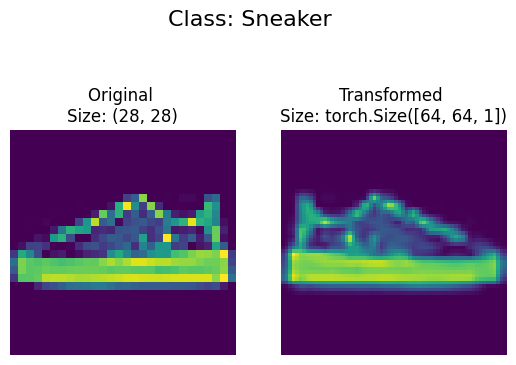

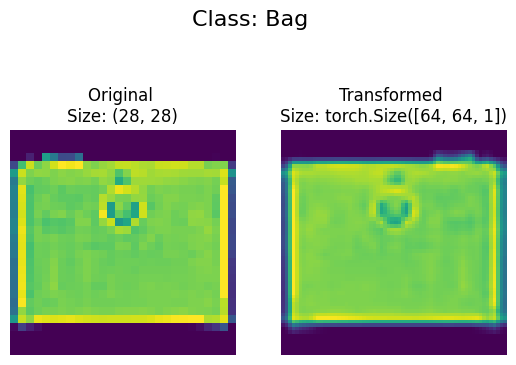

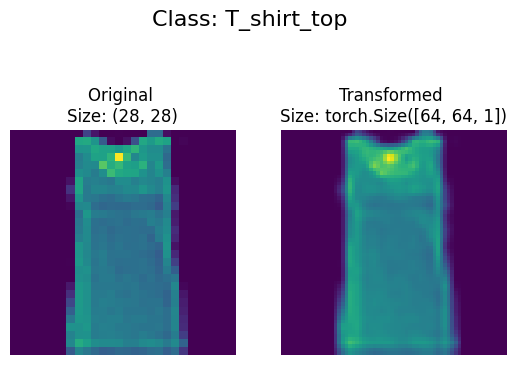

In [34]:
plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

Nice!
We've now got a way to convert our images to tensors using `torchvision.transforms`.

We also manipulate their size and orientation if needed (some models prefer images of different sizes and shapes).

Generally, the larger the shape of the image, the more information a model can recover.

For example, an image of size `[256, 256, 3]` will have 16x more pixels than an image of size `[64, 64, 3]` (`(256*256*3)/(64*64*3)=16`).

However, the tradeoff is that more pixels requires more computations.

> **Exercise:** Try commenting out one of the transforms in `data_transform` and running the plotting function `plot_transformed_images()` again, what happens?

---
## 5. **Option 1:** Loading Image Data Using [`ImageFolder`](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder)
---

Alright, time to turn our image data into a `Dataset` capable of being used with PyTorch.

Since our data is in standard image classification format, we can use the class [`torchvision.datasets.ImageFolder`](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder).

Where we can pass it the file path of a target image directory as well as a series of transforms we'd like to perform on our images.

Let's test it out on our data folders `train_dir` and `test_dir` passing in `transform=data_transform` to turn our images into tensors.

In [35]:
train_dir, test_dir

(PosixPath('data/fashion_mnist_subset/train'),
 PosixPath('data/fashion_mnist_subset/test'))

In [36]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)



In [37]:
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 5000
    Root location: data/fashion_mnist_subset/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 1000
    Root location: data/fashion_mnist_subset/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [38]:
class_names=train_data.classes
class_names

['Ankle_boot',
 'Bag',
 'Coat',
 'Dress',
 'Pullover',
 'Sandal',
 'Shirt',
 'Sneaker',
 'T_shirt_top',
 'Trouser']

In [39]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'Ankle_boot': 0,
 'Bag': 1,
 'Coat': 2,
 'Dress': 3,
 'Pullover': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'T_shirt_top': 8,
 'Trouser': 9}

It looks like PyTorch has registered our `Dataset`'s.

Let's inspect them by checking out the `classes` and `class_to_idx` attributes as well as the lengths of our training and test sets.

In [40]:
# Check the lengths
len(train_data), len(test_data)

(5000, 1000)

i). How about our images and labels?

ii). How do they look?

iii). We can index on our `train_data` and `test_data` `Dataset`'s to find samples and their target labels.

In [41]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Image shape: torch.Size([3, 64, 64])
Image datatype: torch.float32
Image label: 0
Label datatype: <class 'int'>


C,H,W (PyTorch Format) -> H,W,C (Matplotli takes this)

Original shape: torch.Size([3, 64, 64]) -> (CHW)
Shape after permute: torch.Size([64, 64, 3]) -> HWC


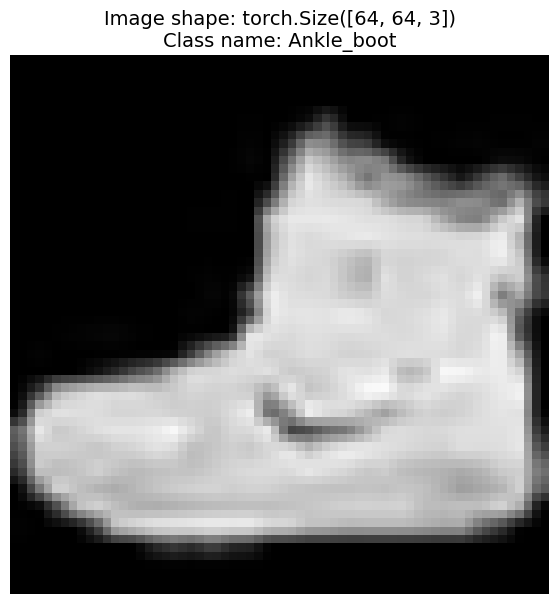

In [42]:
#  Rearrange the order of dimensions
img_permute = img.permute(1,2,0)

# Print out different shapes
print(f"Original shape: {img.shape} -> (CHW)")
print(f"Shape after permute: {img_permute.shape} -> HWC")

# Plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.title(f"Image shape: {img_permute.shape}\nClass name: {class_names[label]}",fontsize=14)
plt.axis(False)
plt.show()

---
### 5.1 Turn loaded images into `DataLoader`'s
---

The ``Dataset`` retrieves our dataset's features and labels one sample at a time. While training a model, we typically want to
pass samples in "minibatches", reshuffle the data at every epoch to reduce model overfitting, and use Python's ``multiprocessing`` to
speed up data retrieval.

``DataLoader`` is an iterable that abstracts this complexity for us in an easy API.


We'll do so using [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

Turning our `Dataset`'s into `DataLoader`'s makes them iterable so a model can go through and learn the relationships between samples and targets (features and labels).

To keep things simple, we'll use a `batch_size=1` and `num_workers=1`.

What's `num_workers`?

Good question.

It defines how many subprocesses will be created to load your data.


Think of it like this, the higher value `num_workers` is set to, the more compute power PyTorch will use to load your data.

Personally, I usually set it to the total number of CPUs on my machine via Python's [`os.cpu_count()`](https://docs.python.org/3/library/os.html#os.cpu_count).

This ensures the `DataLoader` recruits as many cores as possible to load data.

> **Note:** There are more parameters you can get familiar with using `torch.utils.data.DataLoader` in the [PyTorch documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).


In [43]:
BATCH_SIZE=32

In [44]:
os.cpu_count()

2

In [45]:
# Turn train and test datasets into DataLoader's
from torch.utils.data import DataLoader

train_dataloader=DataLoader(dataset=train_data,batch_size=BATCH_SIZE,num_workers=os.cpu_count(),shuffle=True)
test_dataloader=DataLoader(dataset=test_data,
                           batch_size=BATCH_SIZE,
                           num_workers=1,
                           shuffle=False)


In [46]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a55d9c018e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7a55d9d47620>)

In [47]:
len(train_dataloader),len(test_dataloader)

(157, 32)

In [48]:
5000/32

156.25

In [49]:
arr =[1,2,3]
iterable=iter(arr)

In [50]:
for i in arr:
  print(i)

1
2
3


In [51]:
while True:
  try:
    print(next(iterable))
  except StopIteration:
    break

1
2
3


In [52]:
next(iter(train_dataloader))

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0

###**NOTE:** Quick Look at the iterable object

In [53]:
arr=[1,2,3]
iterable=iter(arr)

In [54]:
while True:
  try:
    print(next(iterable))
  except StopIteration:
    break

1
2
3


In [55]:
img,label=next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


---
##6. Creating a Custom Dataset for your files
---


A custom Dataset class must implement three functions: `__init__`, `__len__`, and `__getitem__`.
Take a look at this implementation; the FashionMNIST images are stored
in a directory ``img_dir``, and the images are stored in the folder with name corresponding to their labels.

1. Want to be able to load images from file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from the Dataset

In the next sections, we'll break down what's happening in each of these functions.



In [56]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [57]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes,train_data.class_to_idx

(['Ankle_boot',
  'Bag',
  'Coat',
  'Dress',
  'Pullover',
  'Sandal',
  'Shirt',
  'Sneaker',
  'T_shirt_top',
  'Trouser'],
 {'Ankle_boot': 0,
  'Bag': 1,
  'Coat': 2,
  'Dress': 3,
  'Pullover': 4,
  'Sandal': 5,
  'Shirt': 6,
  'Sneaker': 7,
  'T_shirt_top': 8,
  'Trouser': 9})

---
### 6.1 Creating a helper function to get class names
---

Let's write a helper function capable of creating a list of class names and a dictionary of class names and their indexes given a directory path.

To do so, we'll:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dictionary of numerical labels, one for each class.

Let's see a small example of step 1 before we write the full function.

In [58]:
# Setup path for target directory
target_directory=train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found=sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target directory: data/fashion_mnist_subset/train


['Ankle_boot',
 'Bag',
 'Coat',
 'Dress',
 'Pullover',
 'Sandal',
 'Shirt',
 'Sneaker',
 'T_shirt_top',
 'Trouser']

Exellent!

How about we turn it into a full function?

In [59]:
def find_classes(directory:str)-> Tuple[List[str], Dict[str,int]]:
  # 1. Get the class names by scanning the target directory
  classes=sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classs in {directory}... please check file structure")

  # 3. create a dictionary of index labels (computers prefer numbers rather than strings as labels)
  class_to_idx={class_name:i for i,class_name in enumerate(classes)}
  return classes, class_to_idx

Looking good!

Now let's test out our `find_classes()` function.

In [60]:
find_classes(target_directory)

(['Ankle_boot',
  'Bag',
  'Coat',
  'Dress',
  'Pullover',
  'Sandal',
  'Shirt',
  'Sneaker',
  'T_shirt_top',
  'Trouser'],
 {'Ankle_boot': 0,
  'Bag': 1,
  'Coat': 2,
  'Dress': 3,
  'Pullover': 4,
  'Sandal': 5,
  'Shirt': 6,
  'Sneaker': 7,
  'T_shirt_top': 8,
  'Trouser': 9})

---
### 6.2 Create a custom `Dataset` to replicate `ImageFolder`
---

Now we're ready to build our own custom `Dataset`.

We'll build one to replicate the functionality of `torchvision.datasets.ImageFolder()`.

This will be good practice, plus, it'll reveal a few of the required steps to make your own custom `Dataset`.

Let's break it down:
1. Subclass `torch.utils.data.Dataset`.
2. Initialize our subclass with a `targ_dir` parameter (the target data directory) and `transform` parameter (so we have the option to transform our data if needed).
3. Create several attributes for `paths` (the paths of our target images), `transform` (the transforms we might like to use, this can be `None`), `classes` and `class_to_idx` (from our `find_classes()` function).
4. Create a function to load images from file and return them, this could be using `PIL` or [`torchvision.io`](https://pytorch.org/vision/stable/io.html#image) (for input/output of vision data).
5. Overwrite the `__len__` method of `torch.utils.data.Dataset` to return the number of samples in the `Dataset`, this is recommended but not required. This is so you can call `len(Dataset)`.
6. Overwrite the `__getitem__` method of `torch.utils.data.Dataset` to return a single sample from the `Dataset`, this is required.

Let's do it!


In [61]:
# Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class CustomImageDataset(Dataset):
  # 2. Initialize our custom dataset
  def __init__(self,target_dir:str, transform=None):
    # 3. Create class attributes
    # Get all of the image paths
    self.paths=list(pathlib.Path(target_dir).glob("*/*.png"))
    # Setup Transform
    self.transform=transform
    # Setup classes and class_to_idx attributes
    self.classes,self.class_to_idx=find_classes(target_dir)

  # 4. Create a function to load images
  def load_image(self,index:int)-> Image.Image:
    image_path=self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    return len(self.paths)

  # 6. Override__getitem__() method to return a particular sample
  def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
    img=self.load_image(index)
    class_name=self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx=self.class_to_idx[class_name]

    # Transform if necessary
    if self.transform:
      # print("check")
      return self.transform(img),class_idx #return data,label (X, y)
    else:
      return img,class_idx # untransformed image and label



### ``__init__``

The __init__ function is run once when instantiating the Dataset object. We initialize
the directory containing the images, the annotations file, and both transforms (covered
in more detail in the next section).

The labels.csv file looks like: ::

    tshirt1.jpg, 0
    tshirt2.jpg, 0
    ......
    ankleboot999.jpg, 9



In [62]:
  def __init__(self,target_dir:str, transform=None):
    # 3. Create class attributes
    # Get all of the image paths
    self.paths=list(pathlib.Path(target_dir).glob("*/*.png"))
    # Setup Transform
    self.transform=transform
    # Setup classes and class_to_idx attributes
    self.classes,self.class_to_idx=find_classes(target_dir)


### ``__len__``

The __len__ function returns the number of samples in our dataset.

Example:



In [63]:
  def __len__(self) -> int:
    return len(self.paths)

### ``__getitem__``

The __getitem__ function loads and returns a sample from the dataset at the given index ``idx``.
Based on the index, it identifies the image's location on disk, converts that to a tensor using ``read_image``, retrieves the
corresponding label from the csv data in ``self.img_labels``, calls the transform functions on them (if applicable), and returns the
tensor image and corresponding label in a tuple.



In [64]:
  def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
    img=self.load_image(index)
    class_name=self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx=self.class_to_idx[class_name]

    # Transform if necessary
    if self.transform:
      # print("check")
      return self.transform(img),class_idx #return data,label (X, y)
    else:
      return img,class_idx # untransformed image and label


This is one of the downsides of creating your own custom `Dataset`'s.

However, now we've written it once, we could move it into a `.py` file such as `data_loader.py` along with some other helpful data functions and reuse it later on.

Before we test out our new `CustomImageDataset` class, let's create some transforms to prepare our images.

In [65]:
from IPython.testing import test

from torchvision import transforms

# transform train data
train_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# don't transform test data, only reshape
test_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [66]:
train_dir,test_dir

(PosixPath('data/fashion_mnist_subset/train'),
 PosixPath('data/fashion_mnist_subset/test'))

Now comes the moment of truth!

Let's turn our training images (contained in `train_dir`) and our testing images (contained in `test_dir`) into `Dataset`'s using our own `CustomImageDataset` class.

In [67]:
# Test out CustomImageDataset
train_data_custom = CustomImageDataset(target_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = CustomImageDataset(target_dir=test_dir,
                                     transform=test_transforms)


In [68]:
train_data_custom,test_data_custom

(<__main__.CustomImageDataset at 0x7a55d9c22d20>,
 <__main__.CustomImageDataset at 0x7a55d9c812b0>)

Let's try calling `len()` on our new `Dataset`'s and find the `classes` and `class_to_idx` attributes.

In [69]:
len(train_data),len(train_data_custom)

(5000, 5000)

In [70]:
len(test_data),len(test_data_custom)

(1000, 1000)

In [71]:
train_data_custom.classes

['Ankle_boot',
 'Bag',
 'Coat',
 'Dress',
 'Pullover',
 'Sandal',
 'Shirt',
 'Sneaker',
 'T_shirt_top',
 'Trouser']

In [72]:
train_data_custom.class_to_idx

{'Ankle_boot': 0,
 'Bag': 1,
 'Coat': 2,
 'Dress': 3,
 'Pullover': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'T_shirt_top': 8,
 'Trouser': 9}

In [73]:
# Check for a equality between original ImageFolder Dataset and CustomImageDataset
print(f"train_data.classes == train_data_custom.classes: {train_data.classes==train_data_custom.classes}")
print(f"train_data.class_to_idx == train_data_custom.class_to_idx: {train_data.class_to_idx==train_data_custom.class_to_idx}")
print(f"test_data.classes == test_data_custom.classes: {test_data.classes==test_data_custom.classes}")
print(f"test_data.class_to_idx == test_data_custom.class_to_idx: {test_data.class_to_idx==test_data_custom.class_to_idx}")

train_data.classes == train_data_custom.classes: True
train_data.class_to_idx == train_data_custom.class_to_idx: True
test_data.classes == test_data_custom.classes: True
test_data.class_to_idx == test_data_custom.class_to_idx: True


---
### 6.3 Create a function to display random Images
---


You know what time it is!

Time to put on our data explorer's hat and *visualize, visualize, visualize!*

Let's create a helper function called `display_random_images()` that helps us visualize images in our `Dataset'`s.

Specifically, it'll:
1. Take in a `Dataset` and a number of other parameters such as `classes` (the names of our target classes), the number of images to display (`n`) and a random seed.
2. To prevent the display getting out of hand, we'll cap `n` at 10 images.
3. Set the random seed for reproducible plots (if `seed` is set).
4. Get a list of random sample indexes (we can use Python's `random.sample()` for this) to plot.
5. Setup a `matplotlib` plot.
6. Loop through the random sample indexes found in step 4 and plot them with `matplotlib`.
7. Make sure the sample images are of shape `HWC` (height, width, color channels) so we can plot them.

In [74]:
# 1. Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str]=None,
                          n:int=10,
                          display_shape:bool=True,
                          seed:int=None):
  # 2.Adjust display if n is too high
  if n>10:
    n=10
    display_shape=False
    print(f"For display, purpose, n shouldn't be larger than 10, setting to 10 and removing shape display.")

  # 3. Set the seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx=random.sample(range(len(dataset)),k=n)

  # 5. Set up Plot
  plt.figure(figsize=(16,8))

  # 6. Loop through random indexes and plot them using matplotlib
  for i,target_sample_idx in enumerate(random_samples_idx):
    target_image,target_label=dataset[target_sample_idx][0],dataset[target_sample_idx][1]

    # 7. adjust tensor dims for plotting
    target_image_adjust=target_image.permute(1,2,0)

    # 8. Plot adjusted samples
    plt.subplot(1,n,i+1)
    plt.imshow(target_image_adjust)
    plt.axis(False)
    if classes:
      title=f"class: {classes[target_label]}"
      if display_shape:
        title=f"{title} | \nshape: {target_image_adjust.shape}"
      plt.title(title)

Let's test it out first with the `Dataset` we created with `torchvision.datasets.ImageFolder()`.

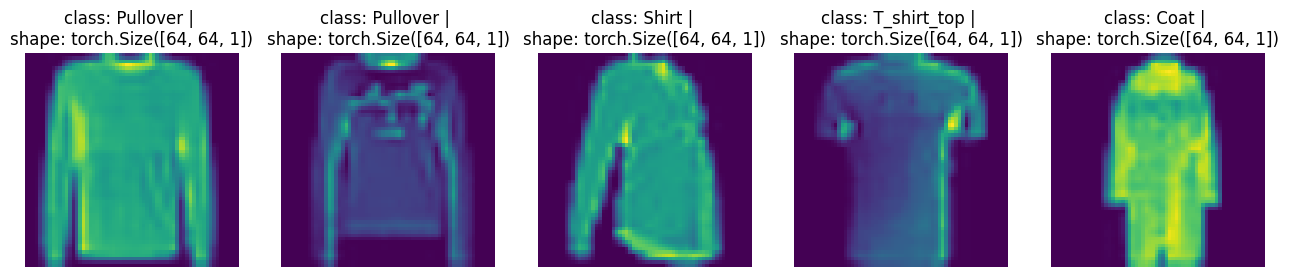

In [75]:
display_random_images(train_data_custom,n=5,classes=class_names,seed=None)

And now with the `Dataset` we created with our own `ImageFolderCustom`.

For display, purpose, n shouldn't be larger than 10, setting to 10 and removing shape display.


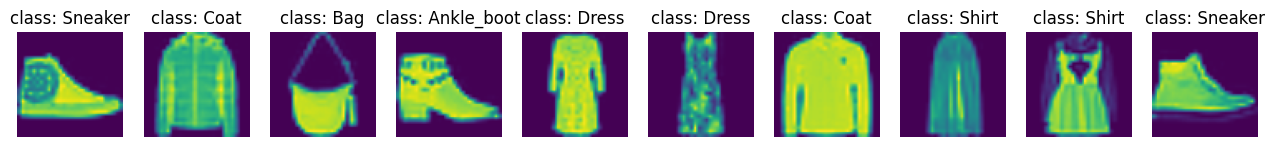

In [76]:
# Display random images from CustomImageDataset
display_random_images(train_data_custom,
                      n=12,
                      classes=class_names,
                      seed=None) # Try setting the seed for reproducible images

Nice!!!

Looks like our `CustomImageDataset` is working just as we'd like it to.

---
###6.4 Preparing your data for training with `DataLoaders`
---

The ``Dataset`` retrieves our dataset's features and labels one sample at a time. While training a model, we typically want to
pass samples in "minibatches", reshuffle the data at every epoch to reduce model overfitting, and use Python's ``multiprocessing`` to
speed up data retrieval.

``DataLoader`` is an iterable that abstracts this complexity for us in an easy API.


We'll do so using [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

Turning our `Dataset`'s into `DataLoader`'s makes them iterable so a model can go through and learn the relationships between samples and targets (features and labels).

To keep things simple, we'll use a `batch_size=1` and `num_workers=1`.

What's `num_workers`?

Good question.

It defines how many subprocesses will be created to load your data.


Think of it like this, the higher value `num_workers` is set to, the more compute power PyTorch will use to load your data.

Personally, I usually set it to the total number of CPUs on my machine via Python's [`os.cpu_count()`](https://docs.python.org/3/library/os.html#os.cpu_count).

This ensures the `DataLoader` recruits as many cores as possible to load data.

> **Note:** There are more parameters you can get familiar with using `torch.utils.data.DataLoader` in the [PyTorch documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).


In [77]:
from torch.utils.data import DataLoader

train_dataloader_custom=DataLoader(dataset=train_data_custom,
                                 batch_size=BATCH_SIZE,
                                 shuffle=True,
                                 num_workers=1)
test_dataloader_custom=DataLoader(dataset=test_data_custom,
                                batch_size=32,
                                shuffle=False,

                                num_workers=0)
train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7a55d9c82270>,
 <torch.utils.data.dataloader.DataLoader at 0x7a55d9e06060>)

What is an iterable object?

In [78]:
img_custom,label_custom=next(iter(train_dataloader_custom))

Wonderful!

Now our data is iterable.

Let's try it out and check the shapes.

In [79]:
img_custom.shape,label_custom.shape

(torch.Size([32, 1, 64, 64]), torch.Size([32]))

---
## 7. Other forms of transforms (data augmentation)
---

We've seen a couple of transforms on our data already but there's plenty more.

You can see them all in the [`torchvision.transforms` documentation](https://pytorch.org/vision/stable/transforms.html).

The purpose of tranforms is to alter your images in some way.

That may be turning your images into a tensor (as we've seen before).

Or cropping it or randomly erasing a portion or randomly rotating them.

Doing these kinds of transforms is often referred to as **data augmentation**.

**Data augmentation** is the process of altering your data in such a way that you *artificially* increase the diversity of your training set.

Training a model on this *artificially* altered dataset hopefully results in a model that is capable of better *generalization* (the patterns it learns are more robust to future unseen examples).

You can see many different examples of data augmentation performed on images using `torchvision.transforms` in PyTorch's [Illustration of Transforms example](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html).

But let's try one out ourselves.

Machine learning is all about harnessing the power of randomness and research shows that random transforms (like [`transforms.RandAugment()`](https://pytorch.org/vision/stable/auto_examples/plot_transforms.html#randaugment) and [`transforms.TrivialAugmentWide()`](https://pytorch.org/vision/stable/auto_examples/plot_transforms.html#trivialaugmentwide)) generally perform better than hand-picked transforms.

The idea behind [TrivialAugment](https://arxiv.org/abs/2103.10158) is... well, trivial.

You have a set of transforms and you randomly pick a number of them to perform on an image and at a random magnitude between a given range (a higher magnitude means more instense).

The PyTorch team even [used TrivialAugment it to train their latest state-of-the-art vision models](https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/#break-down-of-key-accuracy-improvements).

![trivial augment data augmentation being used for PyTorch state of the art training](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-trivial-augment-being-using-in-PyTorch-resize.png)

*TrivialAugment was one of the ingredients used in a recent state of the art training upgrade to various PyTorch vision models.*

How about we test it out on some of our own images?

The main parameter to pay attention to in `transforms.TrivialAugmentWide()` is `num_magnitude_bins=31`.

It defines how much of a range an intensity value will be picked to apply a certain transform, `0` being no range and `31` being maximum range (highest chance for highest intensity).

We can incorporate `transforms.TrivialAugmentWide()` into `transforms.Compose()`.

In [80]:
# Let's look at trivialaugment
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=5),
    transforms.ToTensor()
])

# Don't need to perform augmentation on the test data
test_transforms=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

> **Note:** You usually don't perform data augmentation on the test set. The idea of data augmentation is to to *artificially* increase the diversity of the training set to better predict on the testing set.
>
> However, you do need to make sure your test set images are transformed to tensors. We size the test images to the same size as our training images too, however, inference can be done on different size images if necessary (though this may alter performance).

Beautiful, now we've got a training transform (with data augmentation) and test transform (without data augmentation).

Let's test our data augmentation out!

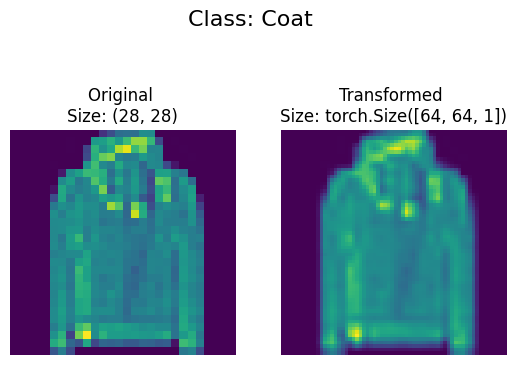

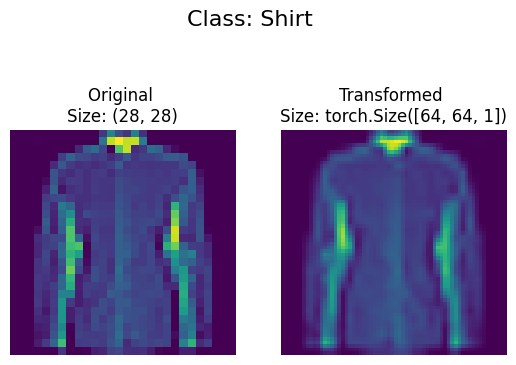

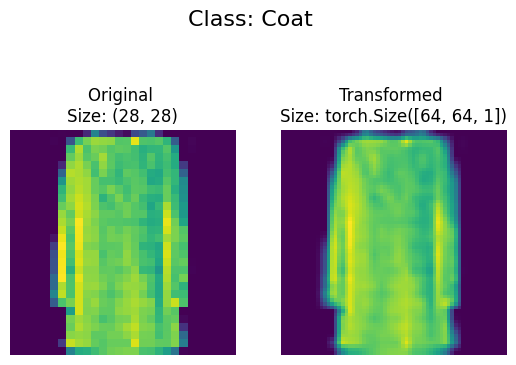

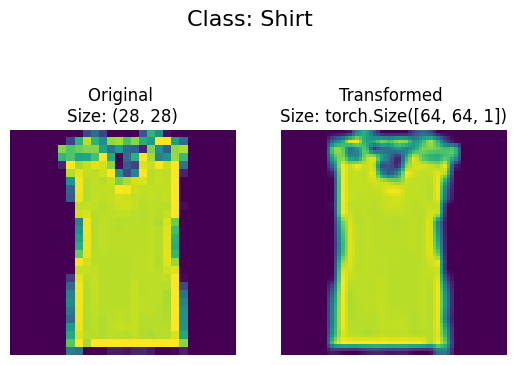

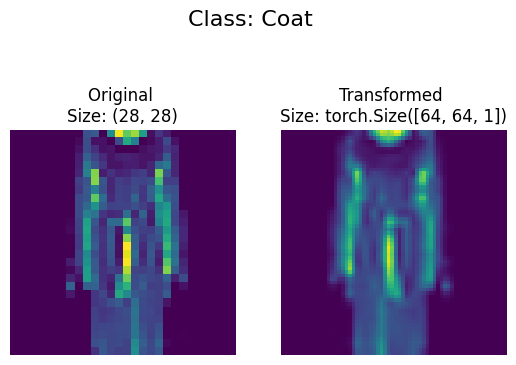

In [81]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.png"))

# Plot random images
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=5,
    seed=None
)

Try running the cell above a few times and seeing how the original image changes as it goes through the transform.

---
## 8. Model 0: TinyVGG without data augmentation
---


### 8.1 Creating transforms and loading data for Model 0

In [82]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

Excellent, now we've got a simple transform, let's:
1. Load the data, turning each of our training and test folders first into a `Dataset` with `torchvision.datasets.ImageFolder()`
2. Then into a `DataLoader` using `torch.utils.data.DataLoader()`.
    * We'll set the `batch_size=32` and `num_workers` to as many CPUs on our machine (this will depend on what machine you're using).

In [83]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. Turn data into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x7a55d9e2c140>,
 <torch.utils.data.dataloader.DataLoader at 0x7a55e9441f40>)

`DataLoader`'s created!

Let's build a model.(...to be continue)